# 05 — Career-Stage Engagement Analysis
Look at engagement by job level, tenure, and time since last promotion to spot stagnation-linked disengagement.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('../data/processed/full_scored.csv')
df.shape

(1470, 38)

## Engagement by job level

In [2]:
df.groupby('JobLevel')[['EngagementIndex']].mean()

,EngagementIndex
JobLevel,
1,0.536581
2,0.536602
3,0.517932
4,0.557461
5,0.544137


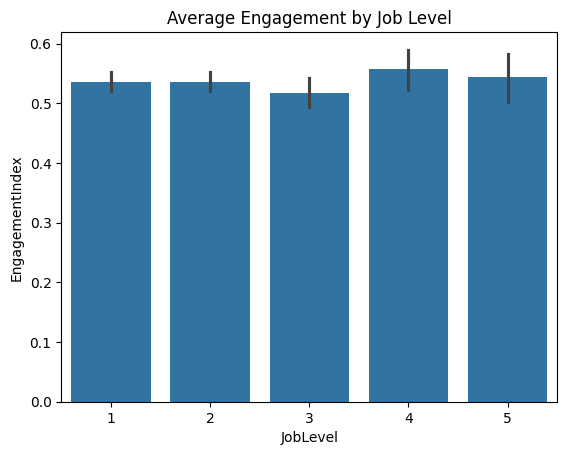

In [3]:
sns.barplot(data=df, x='JobLevel', y='EngagementIndex')
plt.title('Average Engagement by Job Level')
plt.show()

## Engagement by years at company (binned)

In [4]:
bins = [0, 2, 5, 10, 20, 100]
labels = ['0-2', '3-5', '6-10', '11-20', '20+']
df['TenureBand'] = pd.cut(df['YearsAtCompany'], bins=bins, labels=labels, right=True)
df.groupby('TenureBand', observed=True)[['EngagementIndex']].mean()

,EngagementIndex
TenureBand,
0-2,0.534167
3-5,0.529116
6-10,0.543425
11-20,0.535354
20+,0.531680


## Stagnation check: years since last promotion vs engagement
If engagement drops as `YearsSinceLastPromotion` rises, that's a sign employees who feel 'stuck' are disengaging.

In [5]:
df.groupby('YearsSinceLastPromotion')[['EngagementIndex']].mean()

,EngagementIndex
YearsSinceLastPromotion,
0,0.527148
1,0.535269
2,0.560320
3,0.555944
4,0.555887
5,0.559596
6,0.497159
7,0.526316
8,0.565657


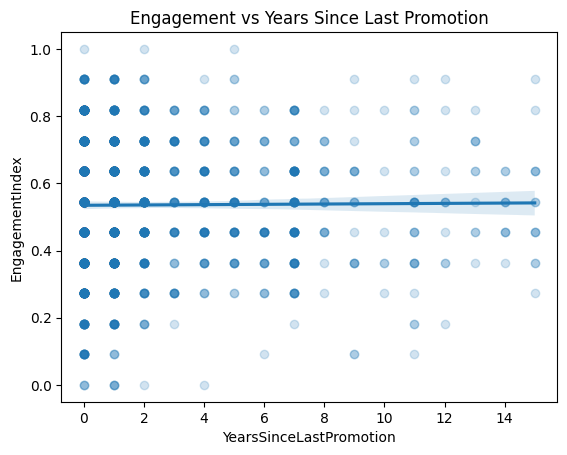

In [6]:
sns.regplot(data=df, x='YearsSinceLastPromotion', y='EngagementIndex',
            scatter_kws={'alpha': 0.2})
plt.title('Engagement vs Years Since Last Promotion')
plt.show()

## Years in current role vs engagement

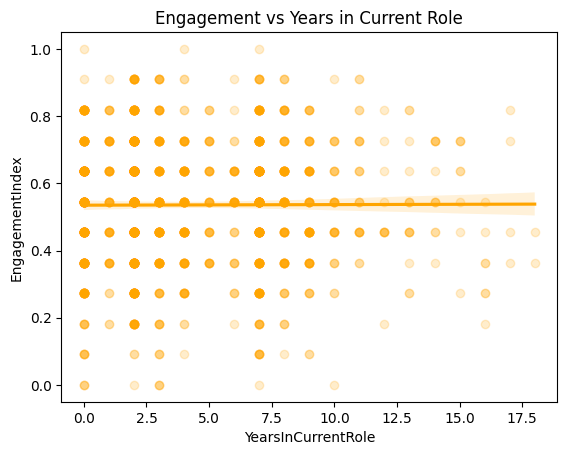

In [7]:
sns.regplot(data=df, x='YearsInCurrentRole', y='EngagementIndex',
            scatter_kws={'alpha': 0.2}, color='orange')
plt.title('Engagement vs Years in Current Role')
plt.show()

## Burnout risk by career stage

In [8]:
pd.crosstab(df['TenureBand'], df['BurnoutRisk'], normalize='index').round(2)

BurnoutRisk,High,Low,Medium
TenureBand,,,
0-2,0.16,0.05,0.79
3-5,0.15,0.07,0.79
6-10,0.12,0.08,0.80
11-20,0.08,0.11,0.81
20+,0.12,0.02,0.86
